In [1]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma', 'filippiny'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма


In [2]:
len(country_name_rus.keys())

84

In [3]:
stemming=False # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [4]:
from stop_words_ru import ru_stopwords

In [5]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [6]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [7]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_25-01-2025.json')     
    df = pd.read_json('Country_DB_V4_25-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_25-01-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_25-01-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [8]:
df_checked

,country,text
0,Судан,судане сезонных наводнений пострадало тысяч че...
1,Судан,срыв американо суданских переговоров каире пер...
10,Турция,глава суверенного совета судана встретился пре...
100,Ирак,президент ирана масуд пезешкиан правительствен...
1000,КНР,китай успешно запустил новую группу спутников ...
...,...,...
995,Иран,иран призвал переосмыслить поведение отношению...
996,Иран,возобновление работы иранского посольства сири...
997,Южная Корея,отстраненному власти президенту грозят новые в...
998,КНР,цзиньпин призвал провинцию хайнань вписать соб...


In [9]:
df

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
9995,Руанда,сми руанда обвинила конго причастности похищен...
9996,Руанда,африканский союз выразил беспокойство кризисом...
9997,Руанда,церковь англии раскритиковала планы правительс...
9998,Руанда,трасс подтвердила британия начнет отправлять н...


In [10]:
len(set(MergeJson["country"].tolist()))

84

In [11]:
for country in set(MergeJson["country"].tolist()): 
    sum = MergeJson[MergeJson["country"]==country]['text'].count()
    print(f'{country} - {sum} ')

КНДР - 395 
Германия - 211 
Зимбабве - 196 
Намибия - 172 
Мозамбик - 236 
Габон - 89 
Афганистан - 463 
Танзания - 217 
Чили - 83 
Иордания - 211 
Пакистан - 260 
Египет - 263 
Ливан - 203 
Судан - 391 
Руанда - 208 
Мали - 301 
КНР (Тайвань) - 211 
Литва - 210 
Ботсвана - 102 
Йемен - 209 
Камбоджа - 70 
Уругвай - 44 
ЮАР - 70 
Мьянма - 199 
Эфиопия  - 346 
Южная Корея - 245 
ДРК (Конго) - 469 
Италия - 207 
Лаос - 206 
Саудовская Аравия - 214 
Бразилия - 243 
Кот-д'Ивуар - 223 
Гана - 231 
Аргентина - 149 
Центрально-Африканская Республика - 545 
Сирия - 141 
Буркина-Фасо - 213 
Республика Конго - 206 
Япония - 270 
Таиланд - 74 
ОАЭ - 385 
Гвинея - 106 
Алжир - 189 
Бурунди - 73 
Индонезия - 182 
Турция - 1133 
Индия - 1406 
Ливия - 327 
Экваториальная Гвинея - 190 
КНР - 2422 
Уганда - 218 
Венгрия - 207 
Замбия - 200 
Оман - 214 
Ангола - 232 
Бангладеш - 121 
Венесуэла - 144 
Сенегал - 152 
Ирак - 69 
Иран - 642 
Боливия - 118 
Нигерия - 250 
Тунис - 125 
Монголия - 88 
Мадагаск

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
len(X)

23703

In [14]:
len(y)

23703

In [15]:
MergeJson

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
995,Иран,иран призвал переосмыслить поведение отношению...
996,Иран,возобновление работы иранского посольства сири...
997,Южная Корея,отстраненному власти президенту грозят новые в...
998,КНР,цзиньпин призвал провинцию хайнань вписать соб...


In [16]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.848) total time=   9.2s
[CV] END ................................ score: (test=0.843) total time=   7.3s
[CV] END ................................ score: (test=0.837) total time=  10.0s
0.8428757567762348
[0.84784574 0.85507683 0.84418324 0.83905967 0.84478602]
[0.82573059 0.82664204 0.81647297 0.8118233  0.82267781]
0.8409474445515911


In [17]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators = [int(x) for x in np.linspace(start = 1200, stop = 1600, num = 10)]
max_features = ['log2', 'sqrt']
max_depth = [int(x) for x in np.linspace(start = 250, stop = 350, num = 10)]
min_samples_split = [int(x) for x in np.linspace(start = 2, stop = 50, num = 10)]
min_samples_leaf = [int(x) for x in np.linspace(start = 2, stop = 20, num = 10)]
bootstrap = [True, False]
param_dist = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split
               }
rs = RandomizedSearchCV(rf_RandomForest, 
                        param_dist, 
                        n_iter = 40, 
                        cv = 3, 
                        verbose = 1, 
                        n_jobs=-1, 
                        random_state=0)
rs.fit(X_train_transformed, y_train)
rs.best_params_
# {'n_estimators': 700,
# 'min_samples_split': 2,
# 'min_samples_leaf': 2,
# 'max_features': 'log2',
# 'max_depth': 11,
# 'bootstrap': True}
#{'n_estimators': 2000,
# 'min_samples_split': 44,
# 'min_samples_leaf': 2,
# 'max_features': 'sqrt',
# 'max_depth': 377}
#{'n_estimators': 1422,
# 'min_samples_split': 12,
# 'max_features': 'log2',
# 'max_depth': 305}

Fitting 3 folds for each of 40 candidates, totalling 120 fits


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
16 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\ML\ML_env\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ML\ML_env\Lib\site-packages\sklearn\ensemble\_forest.py", line 534, in fit
    self._set_oob_score_and_attributes(X, y)
  File "D:\ML\ML_env\Lib

{'n_estimators': 1422,
 'min_samples_split': 12,
 'max_features': 'log2',
 'max_depth': 305}

In [18]:
rs_df = pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
rs_df = rs_df.drop([
            'mean_fit_time', 
            'std_fit_time', 
            'mean_score_time',
            'std_score_time', 
            'params', 
            'split0_test_score', 
            'split1_test_score', 
            'split2_test_score', 
            'std_test_score'],
            axis=1)
rs_df.head(10)

,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,mean_test_score,rank_test_score
0,1422,12,log2,305,0.848842,1
1,1511,12,log2,272,0.848360,2
2,1422,18,log2,316,0.847878,3
3,1466,50,log2,350,0.847637,4
4,1511,23,sqrt,350,0.846914,5
5,1511,28,log2,316,0.846914,6
6,1555,18,sqrt,350,0.846854,7
7,1377,28,sqrt,338,0.846854,8
8,1200,28,sqrt,338,0.846854,9
9,1288,18,sqrt,305,0.846793,10


ValueError: Could not interpret value `param_min_samples_leaf` for `x`. An entry with this name does not appear in `data`.

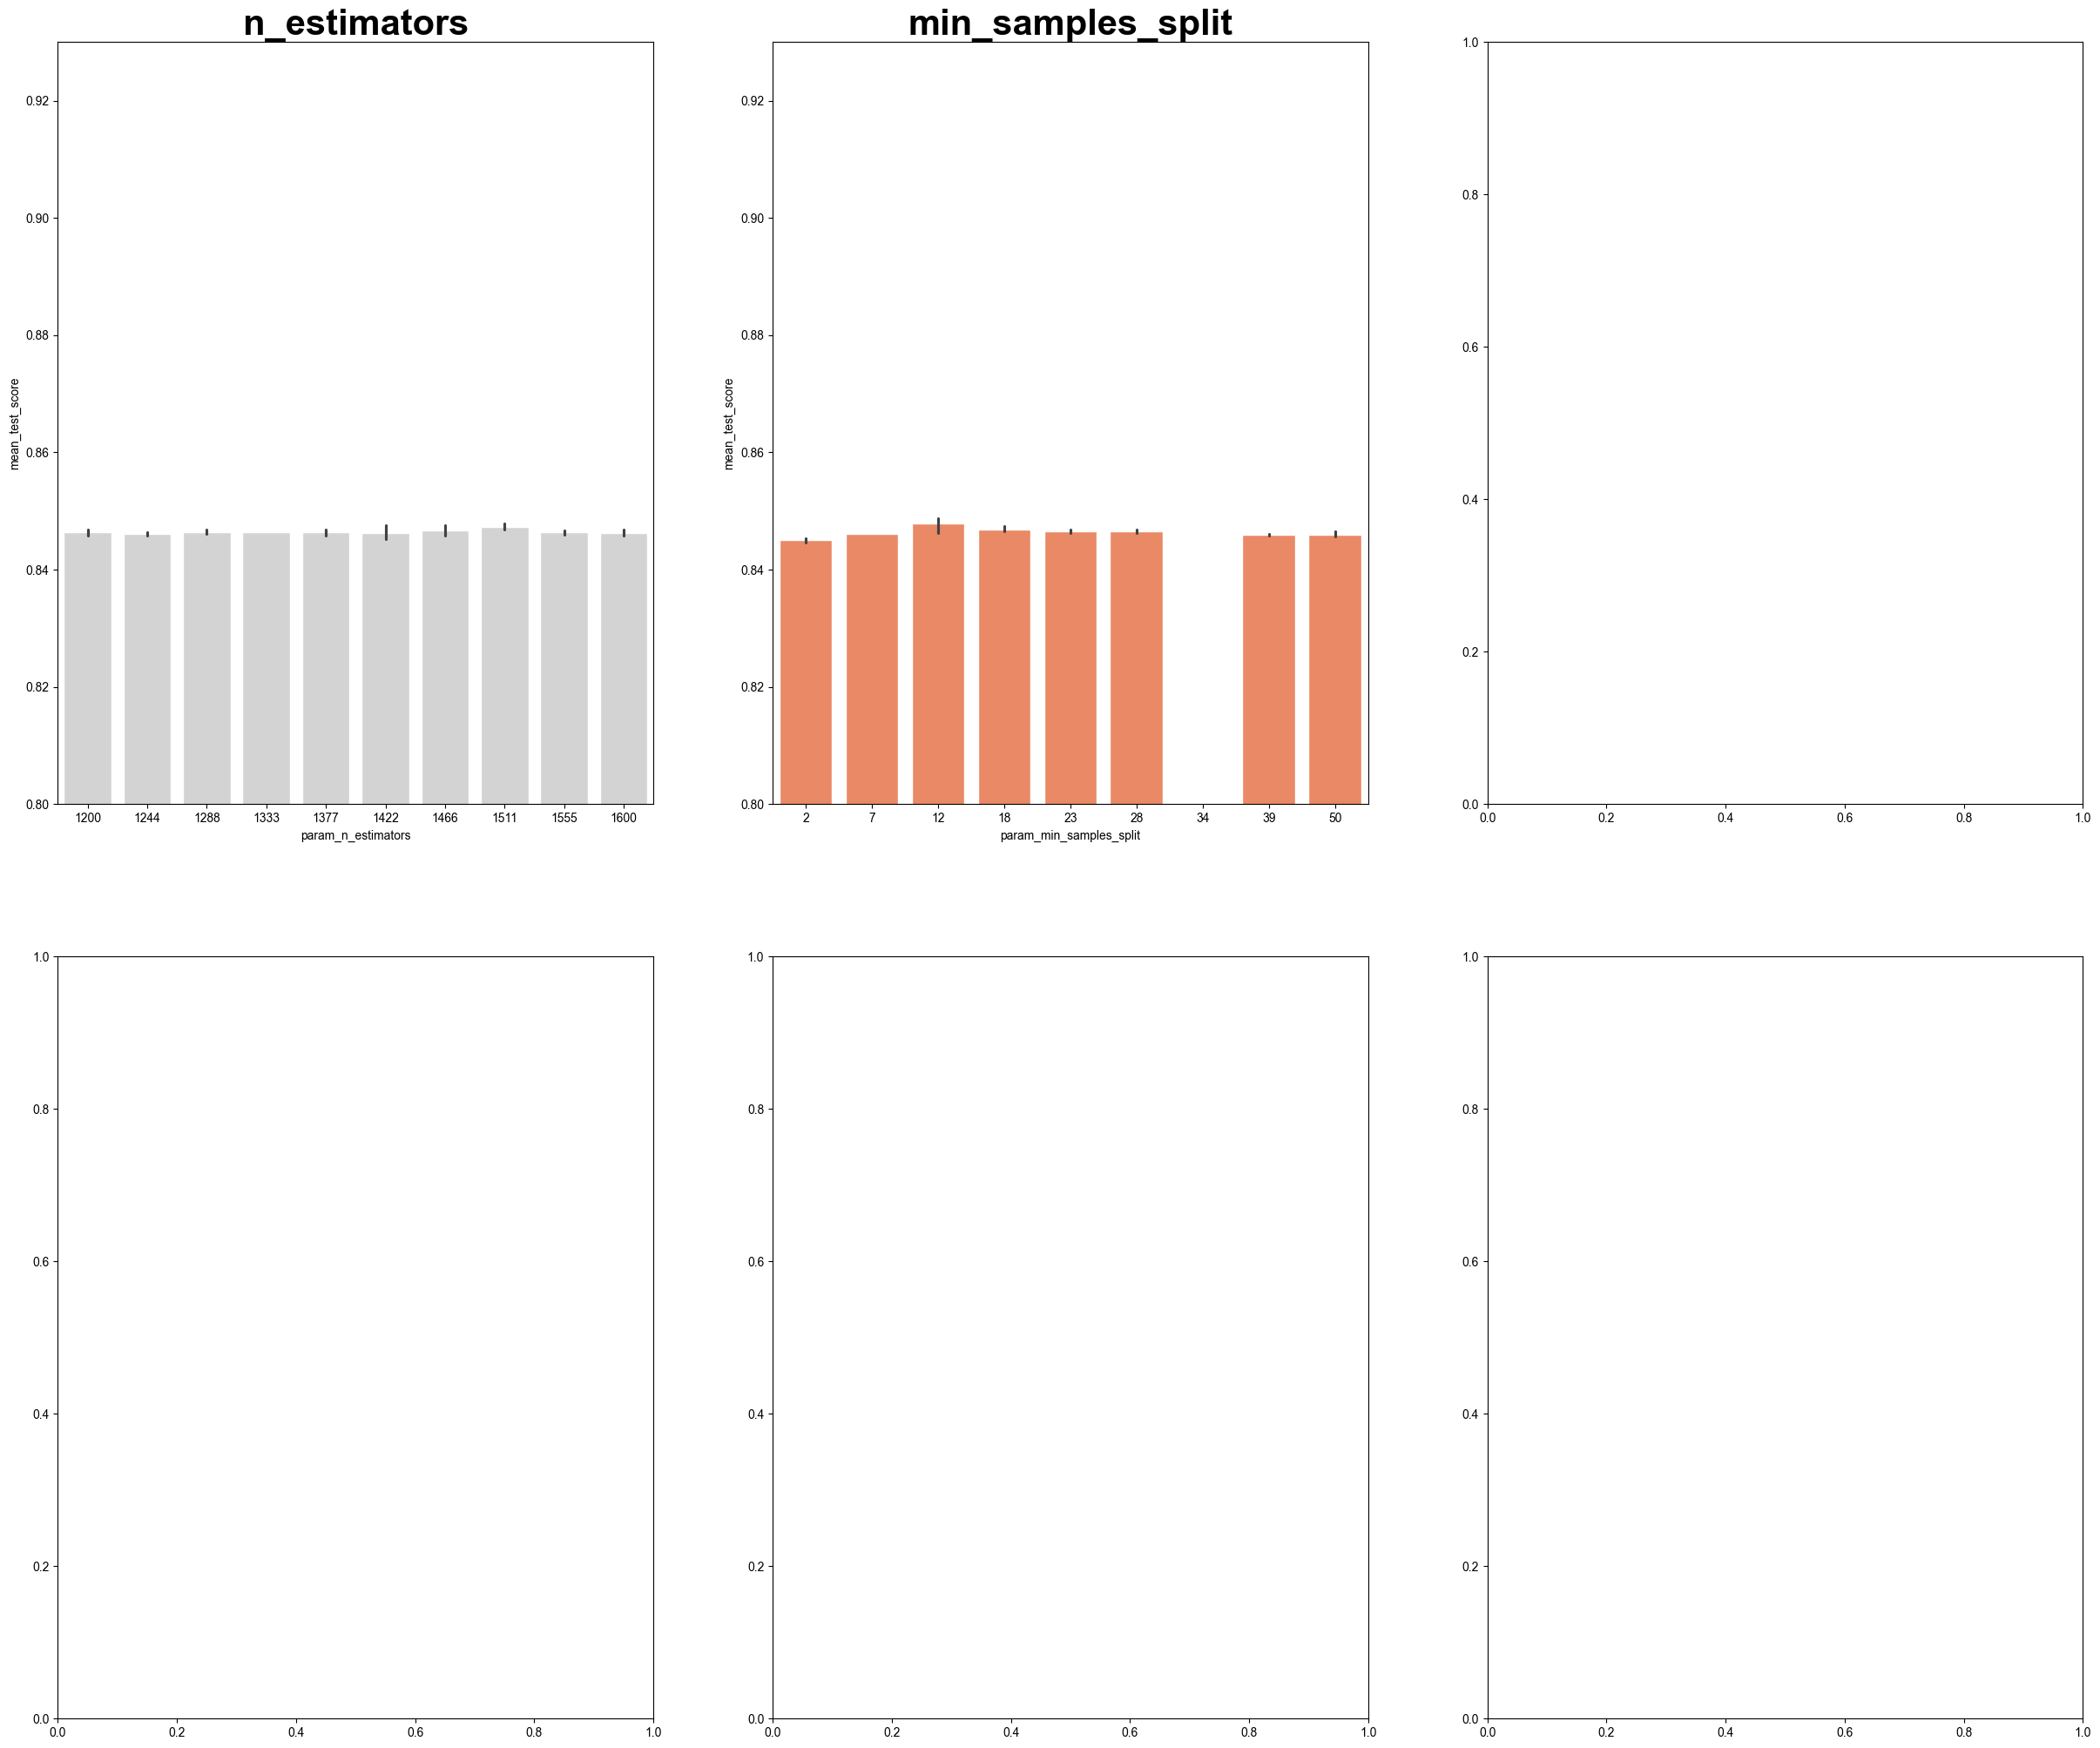

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(ncols=3, nrows=2)
sns.set(style="whitegrid", color_codes=True, font_scale = 2)
fig.set_size_inches(30,25)
sns.barplot(x='param_n_estimators', y='mean_test_score', data=rs_df, ax=axs[0,0], color='lightgrey')
axs[0,0].set_ylim([.8,.93]) 
axs[0,0].set_title(label = 'n_estimators', size=30, weight='bold')
sns.barplot(x='param_min_samples_split', y='mean_test_score', data=rs_df, ax=axs[0,1], color='coral')
axs[0,1].set_ylim([.8,.93]) 
axs[0,1].set_title(label = 'min_samples_split', size=30, weight='bold')
sns.barplot(x='param_min_samples_leaf', y='mean_test_score', data=rs_df, ax=axs[0,2], color='lightgreen')
axs[0,2].set_ylim([.8,.93]) 
axs[0,2].set_title(label = 'min_samples_leaf', size=30, weight='bold')
sns.barplot(x='param_max_features', y='mean_test_score', data=rs_df, ax=axs[1,0], color='wheat')
axs[1,0].set_ylim([.8,.92]) 
axs[1,0].set_title(label = 'max_features', size=30, weight='bold')
sns.barplot(x='param_max_depth', y='mean_test_score', data=rs_df, ax=axs[1,1], color='lightpink')
axs[1,1].set_ylim([.8,.93]) 
axs[1,1].set_title(label = 'max_depth', size=30, weight='bold')
sns.barplot(x='param_bootstrap',y='mean_test_score', data=rs_df, ax=axs[1,2], color='skyblue')
axs[1,2].set_ylim([.8,.92])
axs[1,2].set_title(label = 'bootstrap', size=30, weight='bold')
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
#rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced",
#                                         oob_score=True, n_estimators= 1500, min_samples_split=12,
#                                         min_samples_leaf=2, max_features='log2' ,
#                                        max_depth=272)
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth=120)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.843) total time=   3.7s
[CV] END ................................ score: (test=0.838) total time=   3.7s
[CV] END ................................ score: (test=0.832) total time=   3.6s
0.8376322441030221
[0.84121723 0.85296776 0.83875829 0.8318264  0.83755274]
[0.82251802 0.82706418 0.81447667 0.80561406 0.81834905]
0.8336547733847638


In [32]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted')))

Precision: 97.21%
Recall: 96.58%


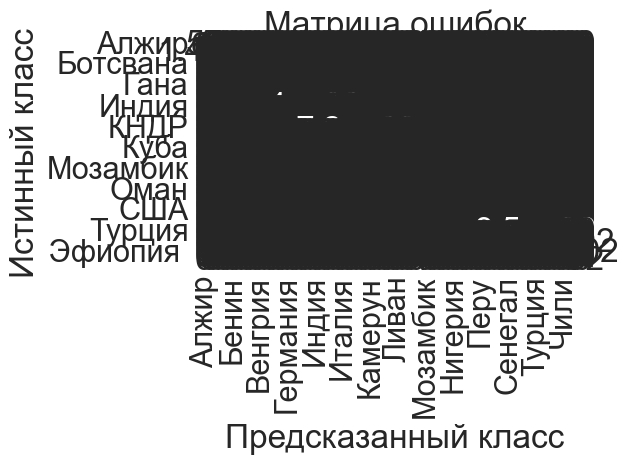

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred_RandomForest)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf_RandomForest.classes_, columns=rf_RandomForest.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [34]:
impoгtances = rf_RandomForest.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

             Word  Importance
9676         чили    0.008739
753       бурунди    0.008645
2737     зимбабве    0.008276
9990       японии    0.008174
5672         перу    0.007427
2527       замбии    0.007373
3363         кндр    0.007041
2934        индии    0.006944
9009       турции    0.006908
3912      марокко    0.006691
9530          цар    0.006651
6109   португалии    0.006581
3801        литвы    0.006503
9900      эфиопии    0.006461
4710      нигерии    0.006257
359     аргентине    0.006021
8986       тунисе    0.005896
3881         мали    0.005868
3095      испании    0.005790
3049     иордании    0.005725
3399     колумбии    0.005692
8739     танзании    0.005653
723      бразилии    0.005605
4440      намибии    0.005527
678       боливии    0.005376
3863  мадагаскаре    0.005321
4295     монголии    0.005213
3287        кении    0.005208
3862  мадагаскара    0.005176
2956    индонезии    0.005143
9074       уганды    0.005124
3215     камбоджи    0.005111
259       

In [35]:
with open('./datasets/feature_importances_nostamm.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

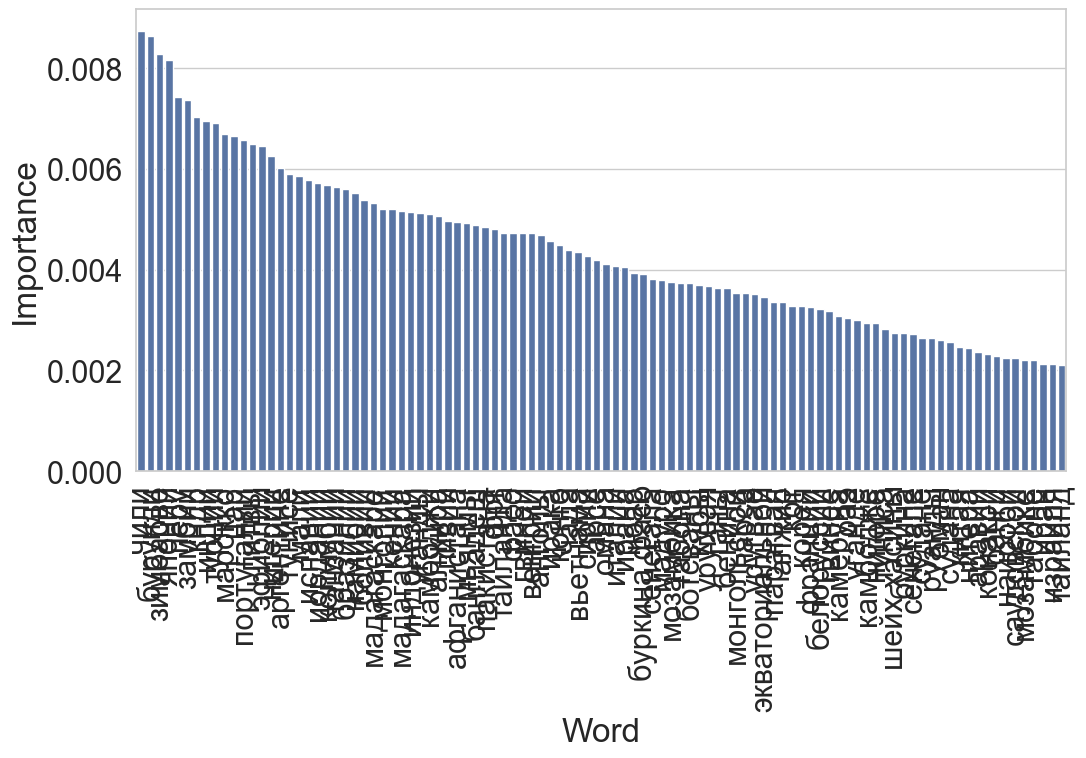

In [36]:
import pandas as pd
import seaborn as sns
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [46]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Почему слова Трампа о присоединении Гренландии надо воспринимать всерьёз — статья Максима Сучкова @postamerica: • Присоединение территорий — обычный способ наращивания государствами мощи. Для лидеров — это ещё и возможность запомниться потомкам, войти в историю. Эгоцентрист-государственник Трамп желает и первого, и второго. Как политик-националист, он стремится укрепить американские позиции в «ближнем зарубежье» США. Как «политик на втором сроке», он хочет, чтобы каждое решение по этой части было стратегическим и долгосрочным, «оставляло наследие». А специфический образ мысли Трампа требует, чтобы это наследие обязательно было грандиозным. • В случае с заявлениями Трампа по поводу Гренландии партнёры Америки находятся в замешательстве: зачем забирать земли у союзников, да ещё в тот момент, когда они третий год подряд убеждают мир в том, что так нельзя и за это надо наказывать? Особенно негодуют французы и датчане, по иронии судьбы, некогда продавшие Соединённым Штатам свои заморские территории: французы — Луизиану в 1803 году (за $15 млн), датчане — Датскую Вест-Индию (современные Американские Виргинские Острова) в 1917 году (за $25 млн). • Трампа, очевидно, не сильно заботит эта реакция. Но ему, вероятно, хочется, чтобы процедура присоединения острова была оформлена красиво — с соблюдением внешних приличий и юридических правил. Провернуть всё это американцам вполне по силам: нация коммерсантов и юристов, по части способности покупать, продавать и обрамлять это изысканной правовой рамкой, равных себе не имеет. • Судя по всему, Трамп нацелен именно на этот сценарий: Трамп-младший слетал в Гренландию, где, по слухам, прощупывал местные лояльные Америке круги, выясняя их готовность организовать референдум о вхождении в состав США; республиканские законодатели в Конгрессе изучают варианты правового оформления этой инициативы; экономисты рассчитывают стоимость возможной сделки — она варьируется в диапазоне от $12,5 млрд до $77 млрд. Параллельно прорабатывается и вариант с долгосрочной арендой острова. • С середины XIX века Гренландия рассматривается США как ключ к контролю над Арктикой. Сегодня Арктика — одна из главных арен великодержавного соперничества. Традиционный инструментарий усиления в этом регионе самих американцев — виртуозно использовать нормотворчество, регламентирующее пользование Арктикой, и стремиться увеличивать площади континентального шельфа. Это они делали задолго до Трампа. • Сам же Трамп убеждён: в то время как конкуренты США укреплялись, Байден и его команда на протяжении четырёх лет только и делали, что бездумно расточали ресурсы страны. Пришла пора собирать камни. Читать статью для @profilejournal'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
from sklearn.feature_extraction.text import CountVectorizer
count = CountVectorizer(ngram_range=(1,5), vocabulary = set(tfidf.get_feature_names_out()))
#count = CountVectorizer(vocabulary = set(X_train_words))
X_t = count.transform(x_temp)
#print(count.vocabulary_)
accuracy = rf_RandomForest.predict(X_t)
print (accuracy)

['Сенегал' 'Мексика' 'КНР' 'Алжир' 'Венесуэла' 'Бразилия' 'США']


In [47]:
probabilities = rf_RandomForest.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest.classes_):
        if probabilities[i][ix]>0.02:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Алжир, Probability = 0.02
 Class Мали, Probability = 0.29
 Class Нигер, Probability = 0.03
 Class Нигерия, Probability = 0.06
 Class Сенегал, Probability = 0.48
 Class Чад, Probability = 0.02
Sample 1
 Class Индия, Probability = 0.03
 Class Индонезия, Probability = 0.03
 Class КНР, Probability = 0.02
 Class Мали, Probability = 0.02
 Class Мексика, Probability = 0.03
 Class Морокко, Probability = 0.02
 Class США, Probability = 0.02
 Class Судан, Probability = 0.03
Sample 2
 Class КНР, Probability = 0.47
 Class Мексика, Probability = 0.02
 Class США, Probability = 0.04
Sample 3
 Class Алжир, Probability = 0.11
 Class Индия, Probability = 0.02
 Class КНР, Probability = 0.02
 Class Мексика, Probability = 0.03
 Class Нигер, Probability = 0.03
 Class США, Probability = 0.02
Sample 4
 Class Венесуэла, Probability = 0.62
 Class Португалия, Probability = 0.02
 Class Турция, Probability = 0.02
 Class Уругвай, Probability = 0.03
Sample 5
 Class Боливия, Probability = 0.13
 Class Б

In [48]:
rf_RandomForest.classes_

array(['Алжир', 'Ангола', 'Аргентина', 'Афганистан', 'Бангладеш',
       'Беларусь', 'Бенин', 'Боливия', 'Ботсвана', 'Бразилия',
       'Буркина-Фасо', 'Бурунди', 'Венгрия', 'Венесуэла', 'Вьетнам',
       'Габон', 'Гана', 'Гвинея', 'Германия', 'ДРК (Конго)', 'Египет',
       'Замбия', 'Зимбабве', 'Израиль', 'Индия', 'Индонезия', 'Иордания',
       'Ирак', 'Иран', 'Испания', 'Италия', 'Йемен', 'КНДР', 'КНР',
       'КНР (Тайвань)', 'Камбоджа', 'Камерун', 'Кения', 'Колумбия',
       "Кот-д'Ивуар", 'Куба', 'Лаос', 'Ливан', 'Ливия', 'Литва',
       'Мадагаскар', 'Мали', 'Мексика', 'Мозамбик', 'Монголия', 'Морокко',
       'Мьянма', 'Намибия', 'Нигер', 'Нигерия', 'ОАЭ', 'Оман', 'Пакистан',
       'Палестина', 'Парагвай', 'Перу', 'Португалия', 'Республика Конго',
       'Руанда', 'США', 'Саудовская Аравия', 'Сенегал', 'Сирия', 'Судан',
       'Таиланд', 'Танзания', 'Тунис', 'Турция', 'Уганда', 'Уругвай',
       'Франция', 'Центрально-Африканская Республика', 'Чад', 'Чили',
       'Экваториал

In [40]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_022_{}_lowRAM_nostamm.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf.get_feature_names_out()], f_out)